In [1]:
from pathlib import Path
import random
import matplotlib.pyplot as plt

from brain_transforms import get_spatial_transform_list 
from data import DicomDataset

In [2]:
data_dir = Path('/data/vision/polina/users/marcusbl/data')

dataset = DicomDataset(data_dir)
dataset.set_norm(mask_method = 'stack')

Loading People Data: 100%|██████████| 30/30 [00:00<00:00, 56.53it/s]


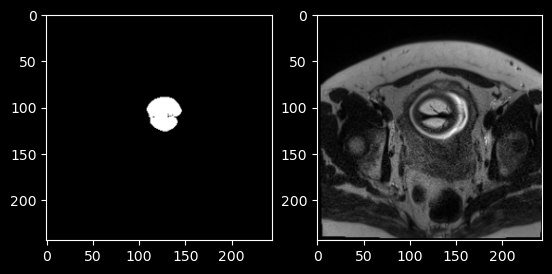

In [64]:
idx = 0

full = dataset[idx][0]

mask = full[1]
scan = full[0]

fig, ax = plt.subplots(ncols = 2)
ax[0].imshow(mask, vmin=0, vmax=1, cmap='grey')
ax[1].imshow(scan, cmap="gray")


bad


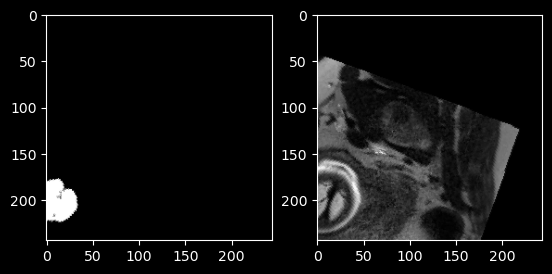

In [59]:
augs = get_spatial_transform_list(trans_perc = 0.40, translate_far = True)
# augs = get_spatial_transform_list(trans_perc = 0.20, translate_far = False)

for transform in augs:
    new_full = transform(full)
    if transform.mask_moves_outside(mask):
        print('bad')

new_mask = new_full[1]
new_scan = new_full[0]

fig, ax = plt.subplots(ncols = 2)
ax[0].imshow(new_mask, vmin=0, vmax=1, cmap='grey')
ax[1].imshow(new_scan, cmap="gray")